### **Imports**

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from matplotlib.animation import FuncAnimation
from IPython.display import Image
from scipy.stats import mode
from scipy.cluster.hierarchy import dendrogram
from scipy.optimize import linear_sum_assignment
from sklearn.datasets import make_blobs, load_iris
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import confusion_matrix, silhouette_score
from sklearn.preprocessing import MinMaxScaler

### **Load data**

#### Iris

In [37]:
df_iris = load_iris()
df_iris = pd.DataFrame(data=df_iris.data, columns=df_iris.feature_names)

In [38]:
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


#### Mall Customer Segmentation

In [39]:
df_mall = pd.read_csv("data/mall_customer_service/Mall_Customers.csv")
df_mall.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### **Task 1**

#### Generating and visualizing synthetic dataset with $n$ distinct clusters

In [40]:
# Generate synthetic data with n clusters
n = 5
X, y = make_blobs(n_samples=700, centers=n, cluster_std=1.0, random_state=42)

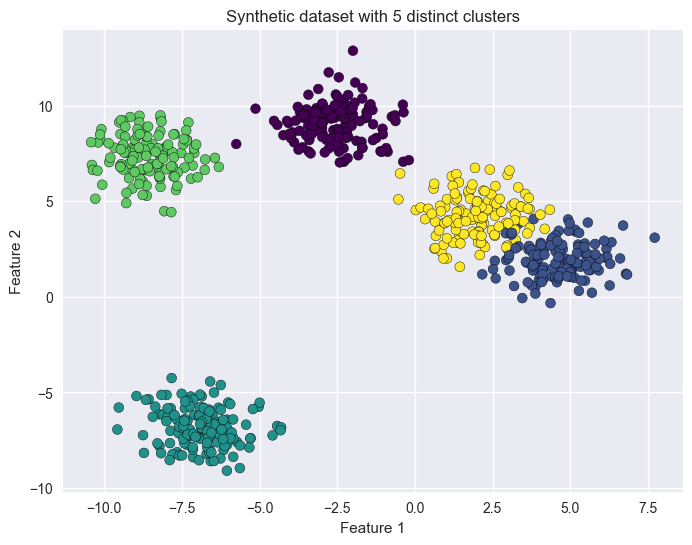

In [41]:
# Create scatter plot
plt.style.use('seaborn-v0_8')
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolor='k')
plt.title(f'Synthetic dataset with {n} distinct clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)

### **Task 2**

#### Creating kmeans algorithm using kmeans++ from scratch

In [42]:
# K-means++ initialization
def initialize_centroids(X, k, random_state=42):
    """
    Initialize centroids using the k-means++ algorithm.
    Returns a NumPy array of shape (k, n_features).
    """
    rng = np.random.default_rng(random_state)
    n_samples, n_features = X.shape

    centroids = np.empty((k, n_features))
    # First centroid chosen randomly
    centroids[0] = X[rng.integers(0, n_samples)]

    # Remaining centroids
    for i in range(1, k):
        dist_sq = np.min(np.linalg.norm(X[:, np.newaxis] - centroids[:i], axis=2) ** 2, axis=1)
        probs = dist_sq / np.sum(dist_sq)
        cumulative_probs = np.cumsum(probs)
        r = rng.random()
        j = np.searchsorted(cumulative_probs, r)
        centroids[i] = X[j]

    return centroids

In [43]:
def assign_clusters(X, centroids):
    """
    Assign each point to the nearest centroid.
    """
    distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
    return np.argmin(distances, axis=1)

In [44]:
def update_centroids(X, labels, k):
    """
    Update centroids as the mean of assigned points.
    """
    return np.array([X[labels == i].mean(axis=0) for i in range(k)])

In [45]:
# K-means main loop
def kmeans(X, k=3, max_iter=10, random_state=42):
    """
    Run k-means clustering with k-means++ initialization.
    Returns centroid history and label history for visualization.
    """
    centroids = initialize_centroids(X, k, random_state)
    centroid_history = [centroids.copy()]
    label_history = []

    for _ in range(max_iter):
        labels = assign_clusters(X, centroids)
        label_history.append(labels)

        new_centroids = update_centroids(X, labels, k)

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids
        centroid_history.append(centroids.copy())

    return centroid_history, label_history

In [46]:
def animate_kmeans(X, centroid_history, label_history, filename="kmeans_animation.gif"):
    """
    Create and save an animation of k-means iterations.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    plt.style.use("seaborn-v0_8")
    def animate(i):
        ax.clear()
        labels = label_history[i]
        centroids = centroid_history[i]

        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="viridis", s=30, edgecolors="k")
        ax.scatter(centroids[:, 0], centroids[:, 1], c="magenta", marker="o", s=70, label = "centroids")
        ax.set_title(f"Kmeans algorithm \n Iteration {i+1}")
        ax.set_xlabel("Feature 1")
        ax.set_ylabel("Feature 2")
        ax.legend()

    ani = FuncAnimation(fig, animate, frames=len(label_history), interval=1000, repeat=False)
    ani.save(filename, writer="pillow")
    plt.close(fig)

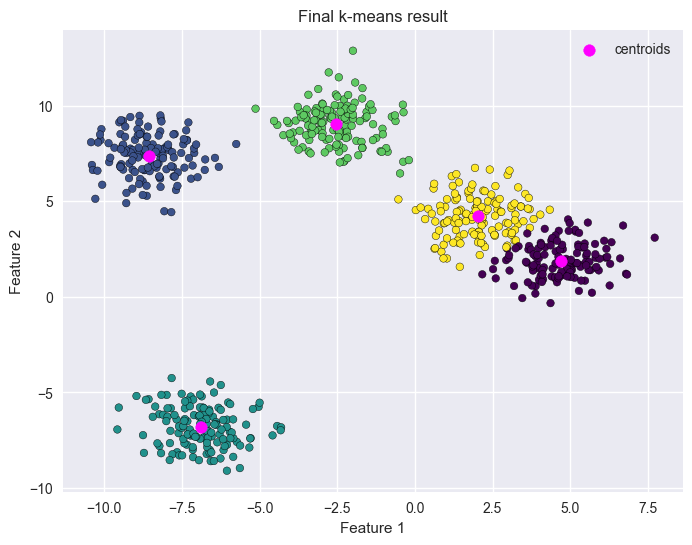

In [47]:
# Run k-means
centroid_history, label_history = kmeans(X, k=n, max_iter=10, random_state=42)

# Final plot
final_labels = label_history[-1]
final_centroids = centroid_history[-1]

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=final_labels, cmap="viridis", s=30, edgecolors="k")
plt.scatter(final_centroids[:, 0], final_centroids[:, 1], c="magenta", marker="o", s=70, label = "centroids")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Final k-means result")
plt.legend()
plt.show()

#### Animation showing the iteration process of the kmeans algorithm

In [48]:
animate_kmeans(X=X, centroid_history=centroid_history, label_history=label_history)

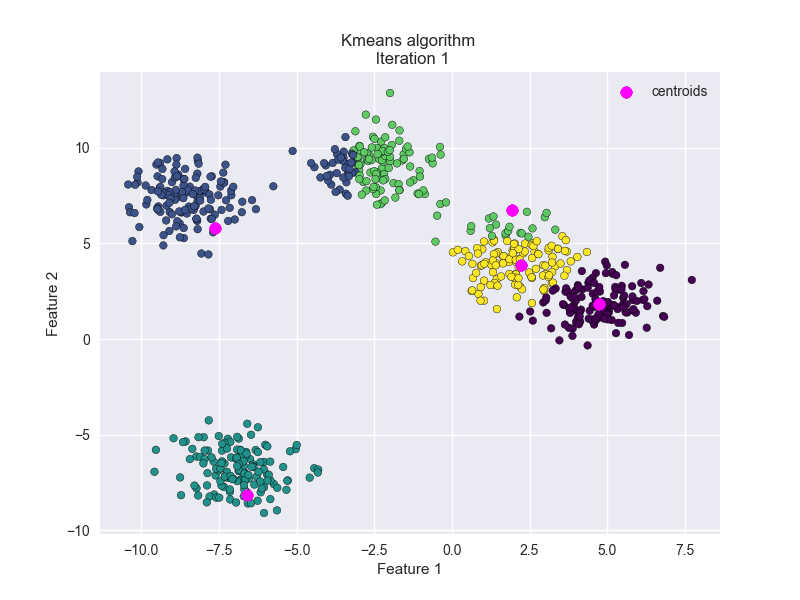

In [49]:
Image(filename="kmeans_animation.gif")

### **Task 3**

#### Using Kmeans from sklearn library

In [50]:
# Initialize the KMeans model with n clusters
kmeans = KMeans(n_clusters=n, random_state=42, n_init=10)

In [51]:
# Train the model on our data X
kmeans.fit(X)
# Get the predicted cluster labels and centroids' coordinates
y_kmeans = kmeans.labels_
centers = kmeans.cluster_centers_

In [52]:
# We want the clusters from each method to be the same color
def remap_labels(true_labels, predicted_labels):
    """
    Remap predicted cluster labels to best match true labels
    using the Hungarian algorithm for one-to-one mapping.
    """
    # Build confusion matrix (rows=true, cols=predicted)
    cm = confusion_matrix(true_labels, predicted_labels)
    
    # Hungarian algorithm maximizes total matches
    # We negate cm because linear_sum_assignment solves a minimization problem
    row_ind, col_ind = linear_sum_assignment(-cm)
    
    # Create mapping dict: predicted -> true
    mapping = {pred: true for true, pred in zip(row_ind, col_ind)}
    
    # Apply mapping
    remapped = np.array([mapping[label] for label in predicted_labels])
    return remapped

In [53]:
# # Remap both sets of predicted labels
y_kmeans_remapped = remap_labels(y, y_kmeans)
final_labels_remapped = remap_labels(y, final_labels)

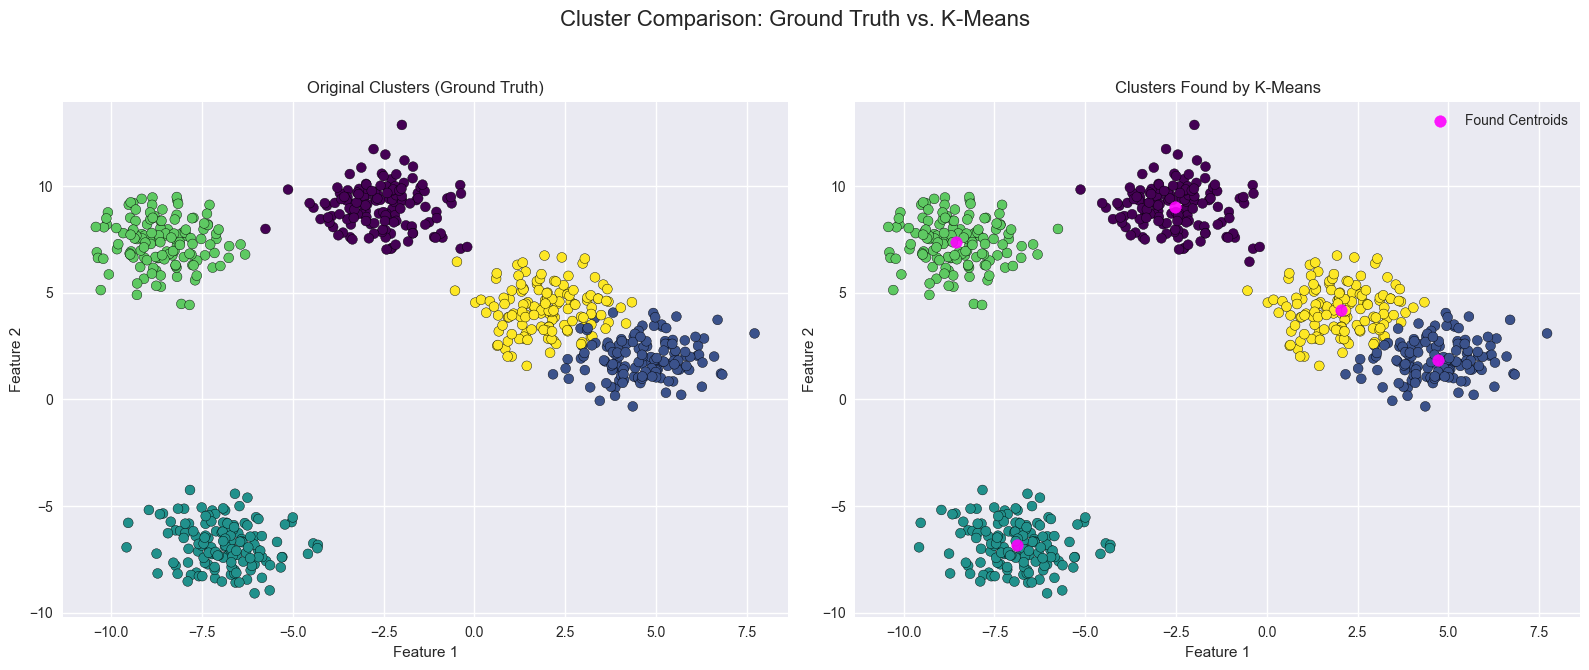

In [54]:
# Set the plot style
plt.style.use('seaborn-v0_8')

# Create a figure with two subplots (1 row, 2 columns)
# This will allow for easy visual comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Subplot 1: Original Clusters
# We use 'y' (the true labels) for coloring
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolor='k')
ax1.set_title(f'Original Clusters (Ground Truth)')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True)

# Subplot 2: Clusters found by K-Means
# We use 'y_kmeans' (labels from K-Means) for coloring
scat = ax2.scatter(X[:, 0], X[:, 1], c=y_kmeans_remapped, cmap='viridis', s=50, edgecolor='k')
# Additionally, we plot the found centroids
ax2.scatter(centers[:, 0], centers[:, 1], c='magenta', s=70, alpha=0.9, 
            marker='o', label='Found Centroids')
ax2.set_title(f'Clusters Found by K-Means')
ax2.set_xlabel('Feature 1')
ax2.set_ylabel('Feature 2')
ax2.legend()
ax2.grid(True)

# Set the main title for the entire figure
plt.suptitle('Cluster Comparison: Ground Truth vs. K-Means', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout
plt.show()

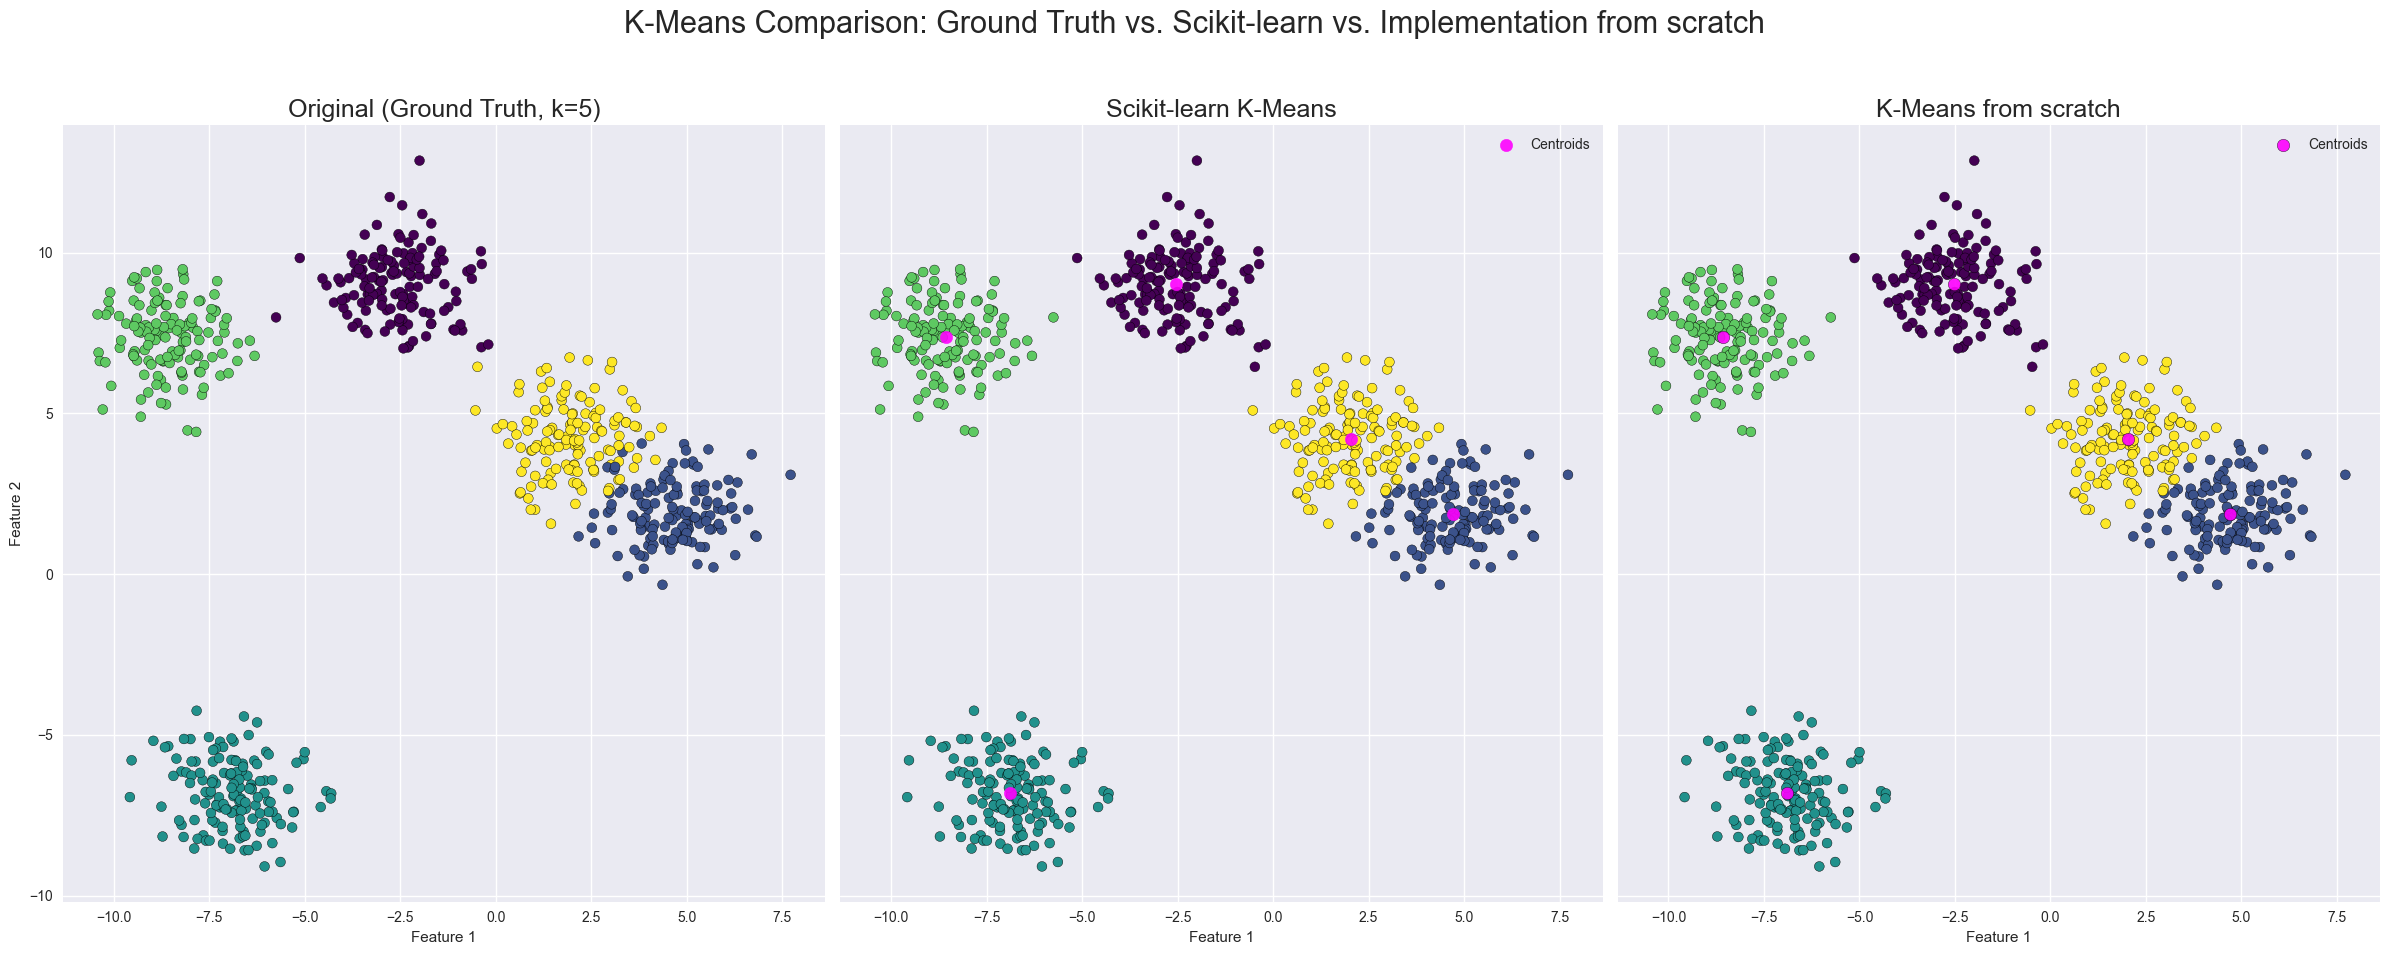

In [55]:
plt.style.use('seaborn-v0_8')
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 10), sharey=True)

# Plot 1: Original (Ground Truth)
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolor='k')
ax1.set_title(f'Original (Ground Truth, k={n})', fontsize = 18)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True)

# Plot 2: Scikit-learn K-Means
ax2.scatter(X[:, 0], X[:, 1], c=y_kmeans_remapped, cmap='viridis', s=50, edgecolor='k')
ax2.scatter(centers[:, 0], centers[:, 1], c='magenta', s=80, 
            alpha=0.9, marker='o', label='Centroids')
ax2.set_title('Scikit-learn K-Means', fontsize = 18)
ax2.set_xlabel('Feature 1')
ax2.legend()
ax2.grid(True)

# Plot 3: Implementation from scratch
ax3.scatter(X[:, 0], X[:, 1], c=final_labels_remapped, cmap="viridis", s=50, edgecolors="k")
ax3.scatter(final_centroids[:, 0], final_centroids[:, 1], c="magenta", 
            marker="o", s=80, label = "Centroids", alpha=0.9,
            edgecolor='black')
ax3.set_title("K-Means from scratch", fontsize = 18)
ax3.set_xlabel("Feature 1")
ax3.legend()
ax3.grid(True)

plt.suptitle('K-Means Comparison: Ground Truth vs. Scikit-learn vs. Implementation from scratch', fontsize=22)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **Task 4**

#### Agglomerative clustering

In [56]:
# Helper Function for Plotting Dendrogram (from scikit-learn docs)
def plot_dendrogram(model, **kwargs):
    """
    Create linkage matrix and then plot the dendrogram
    """
    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


In [57]:
# Apply Agglomerative Clustering
# We will compare 'ward' and 'average' linkage

# Model 1: Ward Linkage
# 'ward' requires Euclidean distance
agg_ward = AgglomerativeClustering(n_clusters=n, linkage='ward')
y_ward = agg_ward.fit_predict(X)

# Model 2: Average Linkage
agg_avg = AgglomerativeClustering(n_clusters=n, linkage='average')
y_avg = agg_avg.fit_predict(X)

# Remap Labels and Calculate Accuracy
y_ward_remapped = remap_labels(y, y_ward)
y_avg_remapped = remap_labels(y, y_avg)

acc_ward = np.mean(y_ward_remapped == y)
acc_avg = np.mean(y_avg_remapped == y)

print(f"Agglomerative Clustering Accuracy (Ward): {acc_ward * 100:.2f}%")
print(f"Agglomerative Clustering Accuracy (Average): {acc_avg * 100:.2f}%")

Agglomerative Clustering Accuracy (Ward): 98.29%
Agglomerative Clustering Accuracy (Average): 79.71%


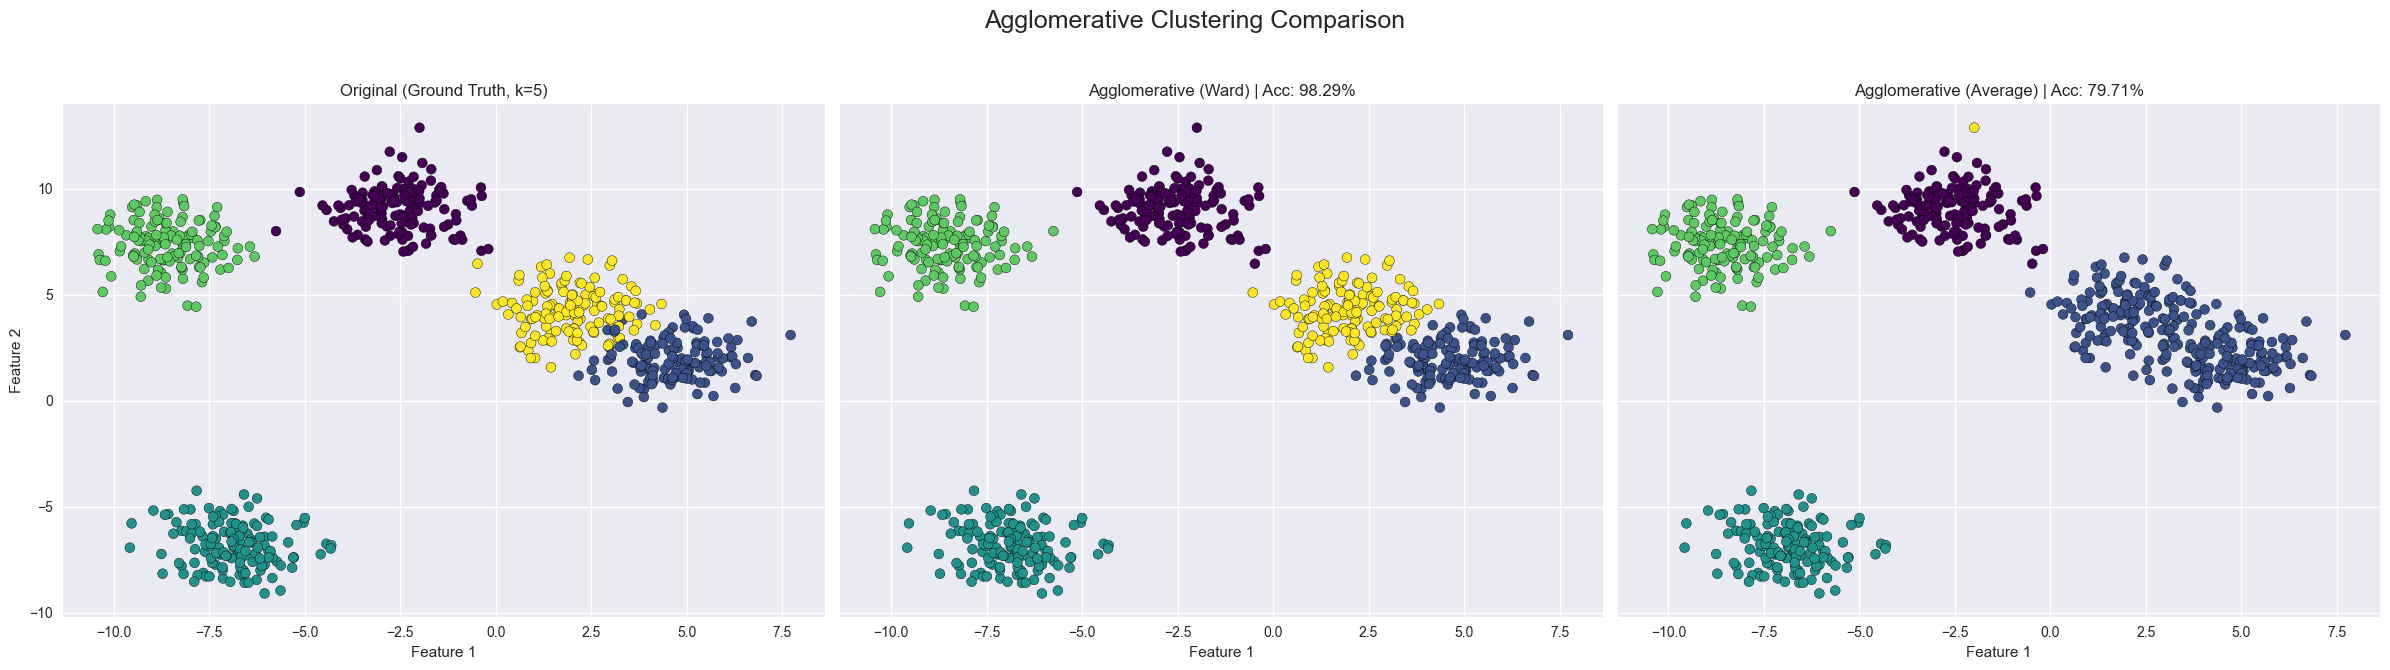

In [58]:
# Visualization (1 row, 3 columns)
plt.style.use('seaborn-v0_8')
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

# Plot 1: Original (Ground Truth)
ax1.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, edgecolor='k')
ax1.set_title(f'Original (Ground Truth, k={n})')
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')
ax1.grid(True)

# Plot 2: Agglomerative (Ward)
ax2.scatter(X[:, 0], X[:, 1], c=y_ward_remapped, cmap='viridis', s=50, edgecolor='k')
ax2.set_title(f'Agglomerative (Ward) | Acc: {acc_ward * 100:.2f}%')
ax2.set_xlabel('Feature 1')
ax2.grid(True)

# Plot 3: Agglomerative (Average)
ax3.scatter(X[:, 0], X[:, 1], c=y_avg_remapped, cmap="viridis", s=50, edgecolors="k")
ax3.set_title(f"Agglomerative (Average) | Acc: {acc_avg * 100:.2f}%")
ax3.set_xlabel("Feature 1")
ax3.grid(True)

plt.suptitle('Agglomerative Clustering Comparison', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

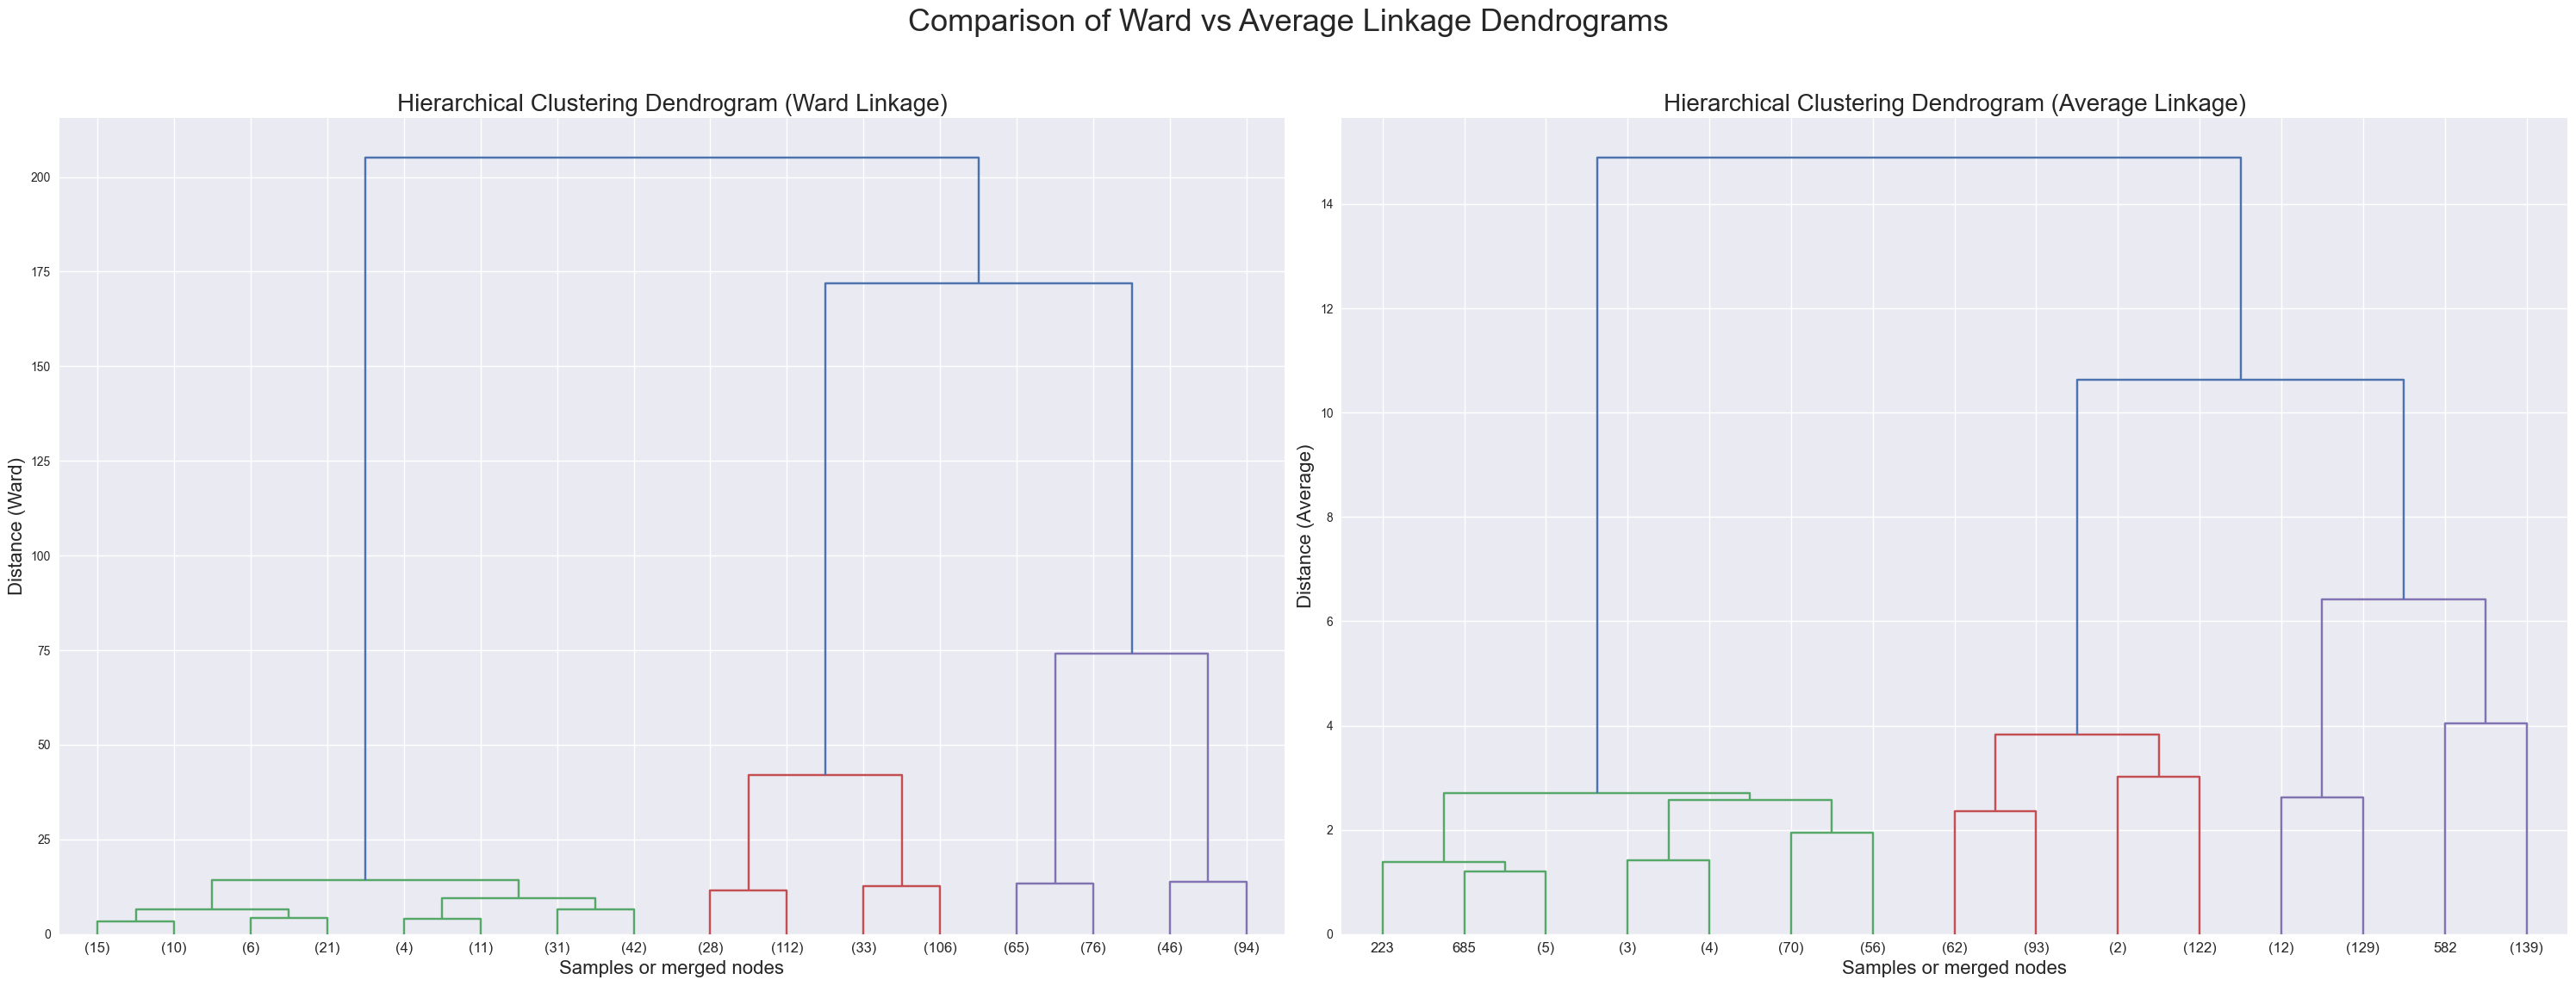

In [59]:
# Plot Dendrogram using AgglomerativeClustering

# We must create a new model with distance_threshold=0 and n_clusters=None
# to compute the full tree, which is needed for the dendrogram.
model_dendro_ward = AgglomerativeClustering(distance_threshold=0, 
                                       n_clusters=None, 
                                       linkage='ward')
model_dendro_ward = model_dendro_ward.fit(X)
model_dendro_avg = AgglomerativeClustering(distance_threshold=0, 
                                       n_clusters=None, 
                                       linkage='average')
model_dendro_avg = model_dendro_avg.fit(X)

# Side-by-side dendrograms for Ward and Average linkage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 12))

# Ward linkage dendrogram
ax1.set_title("Hierarchical Clustering Dendrogram (Ward Linkage)", fontsize = 20)
plot_dendrogram(model_dendro_ward, ax=ax1, truncate_mode="level", p=3)
ax1.set_xlabel("Samples or merged nodes", fontsize = 16)
ax1.set_ylabel("Distance (Ward)", fontsize = 16)

# Average linkage dendrogram
ax2.set_title("Hierarchical Clustering Dendrogram (Average Linkage)", fontsize = 20)
plot_dendrogram(model_dendro_avg, ax=ax2, truncate_mode="level", p=3)
ax2.set_xlabel("Samples or merged nodes", fontsize = 16)
ax2.set_ylabel("Distance (Average)", fontsize = 16)

plt.suptitle("Comparison of Ward vs Average Linkage Dendrograms", fontsize=26)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


#### At each step, **Ward** merges the two clusters that result in the smallest increase in total within-cluster variance. Effect on structure: produces compact, spherical clusters (similar to k-means) and strongly resists merging clusters that are distinct in variance or spread.
#### At each step, **Average linkage** merges the two clusters with the smallest average pairwise distance between their points. Effect on structure: more sensitive to cluster proximity than to variance and can merge two nearby clusters even if they are distinct, especially if one is sparse or small.

### **Task 5**

#### Using the **Elbow method** and **Silhouette value** to find the optimal number of clusters in Iris dataset.

In [60]:
X = df_iris.values
# Range of k values to test
K = range(2, 11)

# Store metrics
inertias = []
silhouette_scores = []
inertia_0 = KMeans(n_clusters=1, random_state=42, n_init=10).fit(X)
inertias.append(inertia_0.inertia_)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    inertias.append(kmeans.inertia_)  # Sum of squared distances
    silhouette_scores.append(silhouette_score(X, labels))

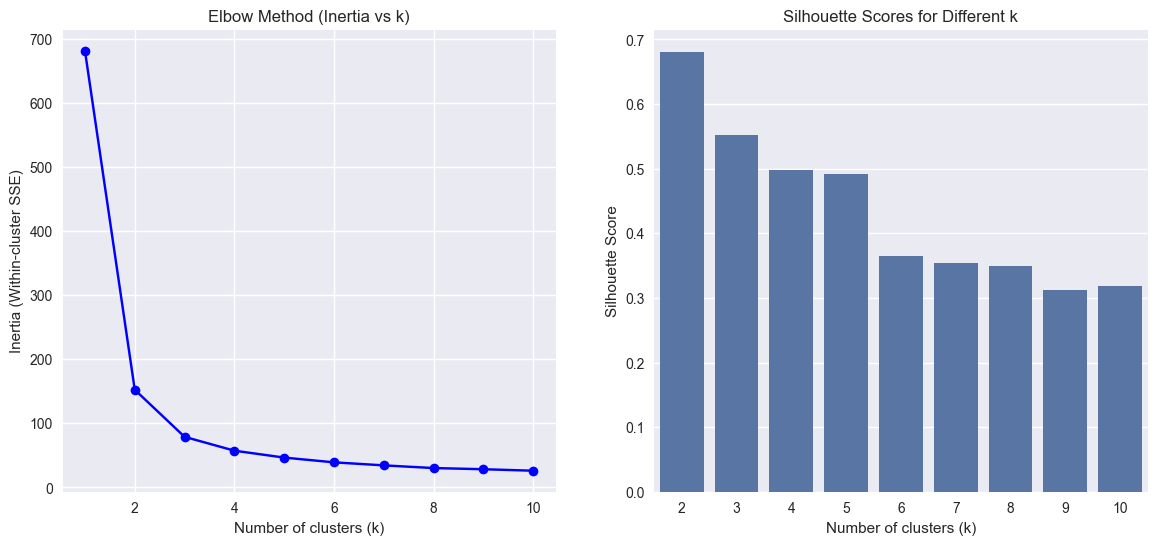

In [61]:
# Plot Elbow Method
plt.figure(figsize=(14, 6))
inertias_len = range(1,len(inertias)+1)
plt.subplot(1, 2, 1)
plt.plot(inertias_len, inertias, 'o-', color='blue')
plt.title("Elbow Method (Inertia vs k)")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (Within-cluster SSE)")
plt.grid(True)

# Plot Silhouette Scores
plt.subplot(1, 2, 2)
sns.barplot(x=K, y=silhouette_scores)
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Different k")
plt.show()

In [62]:
def find_elbow_point(K, inertias):
    """
    Find the elbow point in an inertia curve using the 'maximum distance to line' method.
    """
    K = np.array(K)
    inertias = np.array(inertias)

    # Line endpoints
    x1, y1 = K[0], inertias[0]
    x2, y2 = K[-1], inertias[-1]

    distances = []
    for i in range(len(K)):
        x0, y0 = K[i], inertias[i]
        # Perpendicular distance from point (x0,y0) to line (x1,y1)-(x2,y2)
        d = abs((x2 - x1)*(y1 - y0) - (x1 - x0)*(y2 - y1)) / np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
        distances.append(d)

    elbow_idx = np.argmax(distances)
    return K[elbow_idx]

In [63]:
optimal_k_elbow = find_elbow_point(K, inertias)
print("Elbow method suggests k =", optimal_k_elbow)

# Find the index of the maximum silhouette score
best_idx = np.argmax(silhouette_scores)
# Get the corresponding k
best_k_silhouette = K[best_idx]
print("Silhouette method suggests k =", best_k_silhouette)

Elbow method suggests k = 3
Silhouette method suggests k = 2


### **Task 6**

#### Using Density-Based Spatial Clustering of Applications with Noise with various parameters settings.

##### **Parameters explanation**:
##### *eps* - the maximum distance between two samples for one to be considered as in the neighborhood of the other. This is not a maximum bound on the distances of points within a cluster;
##### *min-samples* - the number of samples (or total weight) in a neighborhood for a point to be considered as a core point. This includes the point itself. If min_samples is set to a higher value, DBSCAN will find denser clusters, whereas if it is set to a lower value, the found clusters will be more sparse.

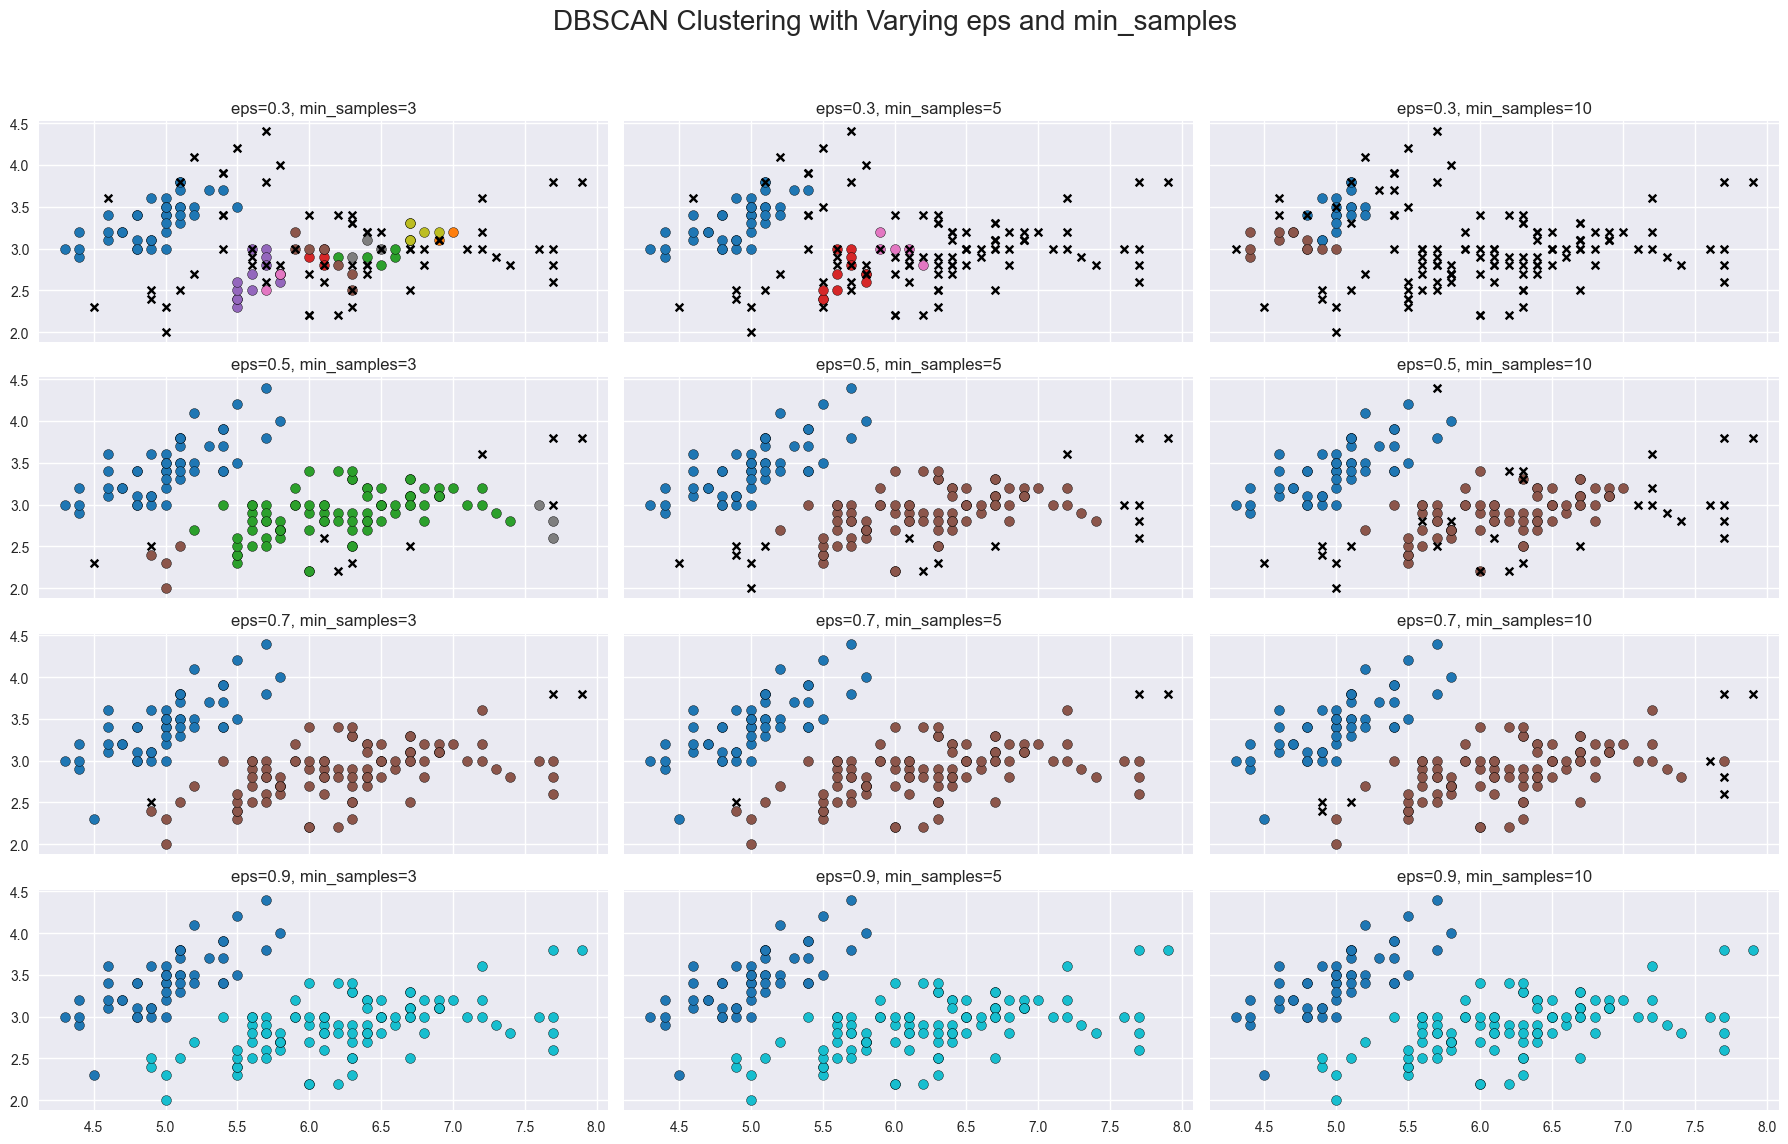

In [64]:
# Parameter grids
eps_values = [0.3, 0.5, 0.7, 0.9]
min_samples_values = [3, 5, 10]

plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(len(eps_values), len(min_samples_values), figsize=(18, 12), sharex=True, sharey=True)

for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X)

        ax = axes[i, j]
        unique_labels = set(labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

        for k, col in zip(unique_labels, colors):
            if k == -1:
                # Noise points
                ax.scatter(X[labels == k, 0], X[labels == k, 1], c="k", marker="x", s=30, label="Noise")
            else:
                ax.scatter(X[labels == k, 0], X[labels == k, 1], c=[col], s=50, edgecolor="k", label=f"Cluster {k}")

        ax.set_title(f"eps={eps}, min_samples={min_samples}")
        ax.grid(True)

plt.suptitle("DBSCAN Clustering with Varying eps and min_samples", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### **Task 7**

#### Analysis of Mall Customer Segmentation Data

In [65]:
display(df_mall.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None

#### **Spending score / Annual Income**

Text(0.5, 1.0, 'Mall Customers')

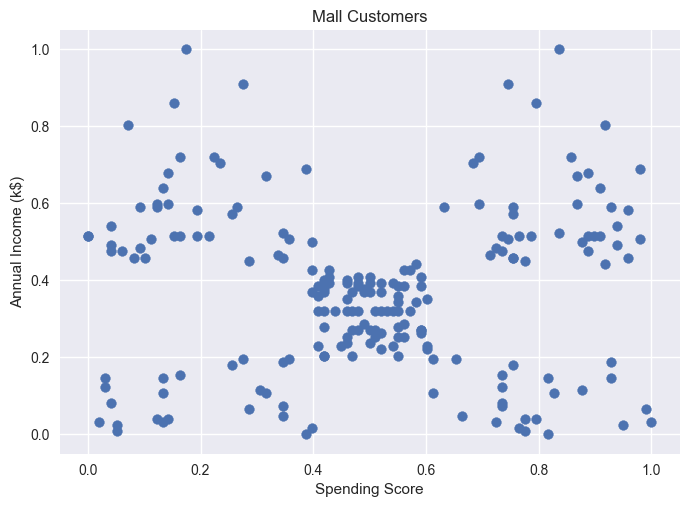

In [66]:
X = df_mall[['Spending Score (1-100)', 'Annual Income (k$)']].values
# Scale features to [0,1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.xlabel("Spending Score")
plt.ylabel("Annual Income (k$)")
plt.title("Mall Customers")

In [67]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

df_mall['Cluster'] = labels

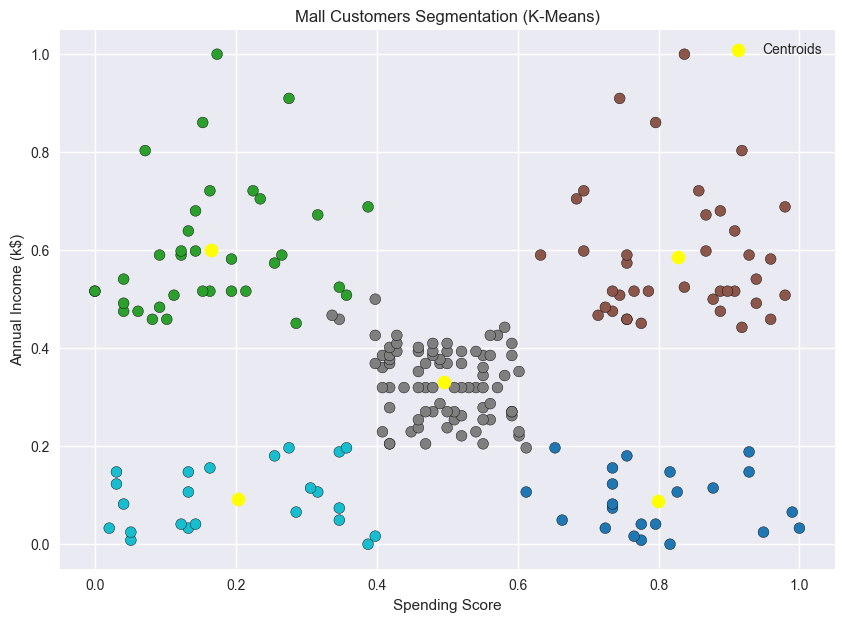

In [68]:
plt.figure(figsize=(10, 7))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='tab10', s=60, edgecolor='k')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='yellow', marker='o', s=90, label='Centroids')
plt.xlabel("Spending Score")
plt.ylabel("Annual Income (k$)")
plt.title("Mall Customers Segmentation (K-Means)")
plt.legend()
plt.grid(True)
plt.show()

#### Groups: High Income and low spending score, high income and high spending score, middle group, low income and low spending score and low income and high spending score.

#### **Age / Spending score**

Text(0.5, 1.0, 'Mall Customers')

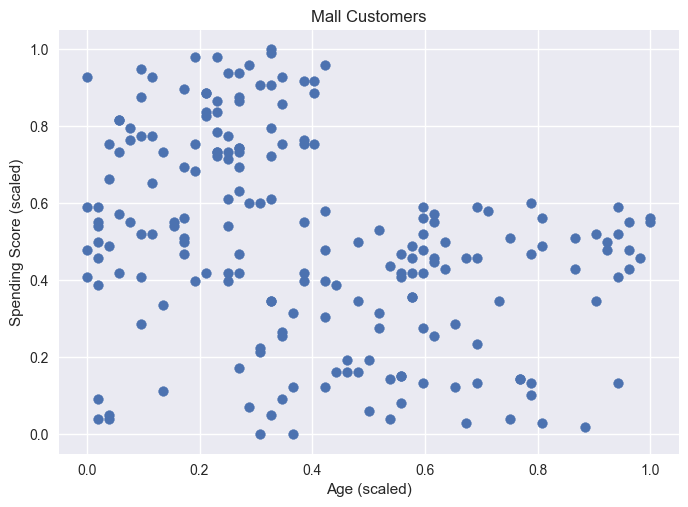

In [69]:
X = df_mall[['Age', 'Spending Score (1-100)']].values
# Scale features to [0,1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1])
plt.xlabel("Age (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Mall Customers")

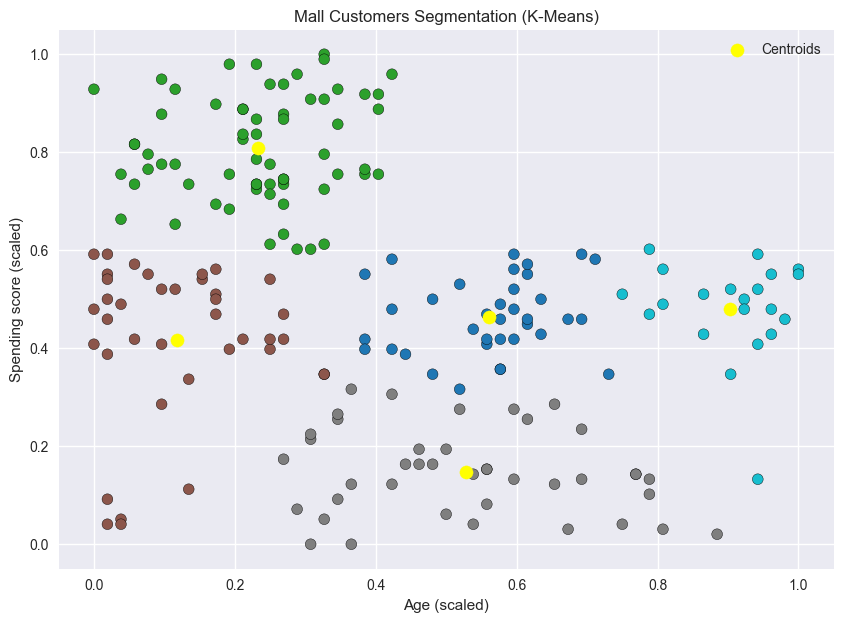

In [70]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)
df_mall['Cluster'] = labels
plt.figure(figsize=(10, 7))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap='tab10', s=60, edgecolor='k')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='yellow', marker='o', s=90, label='Centroids')
plt.xlabel("Age (scaled)")
plt.ylabel("Spending score (scaled)")
plt.title("Mall Customers Segmentation (K-Means)")
plt.legend()
plt.grid(True)
plt.show()

#### Groups: Young with high spending score, young with middle to low spending score, middle (by age) with middle spending score, old with middle spending score, middle (by age) and old with low spending score.